In [1]:
import numpy as np
import pandas as pd
import json
import os
import glob
from typing import Dict, List
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math

In [2]:
# Cell 1: Import and setup
import sys
import os
sys.path.append('retry')

from main_simulation import GeneralSimulationRunner, rerun_failed_comsol, rerun_failed_electrokitty, rerun_failed_digisim, rerun_list_comsol

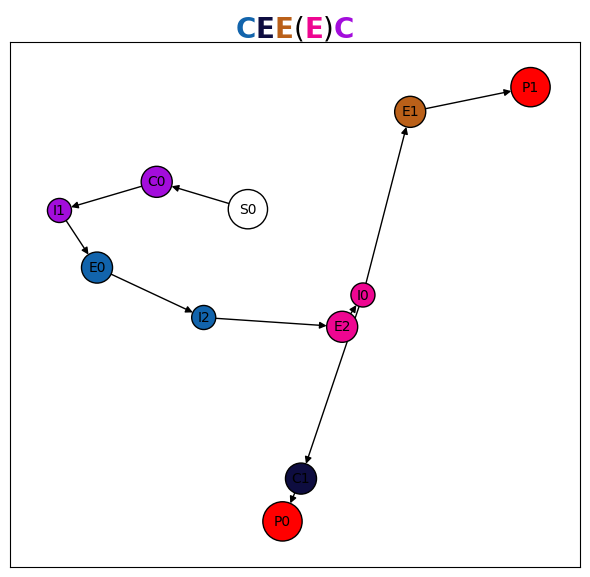

In [3]:
from simulation_utils import *
my_graph = generate_good_ce_digraph(num_nodes = 5, ce_ratio = 0.4, sparsity = 0.01, num_final_steps=2, random_state = 2)
my_graph_fleshed = insert_intermediates(my_graph)
unparser = SynthesisUnparser(my_graph)
text = unparser.to_string_with_markers()
draw_special(my_graph_fleshed, text)
print()

In [4]:
from simulation_utils import *
import random
from typing import Set

def _generate_single_mechanism(seed = 1):
    random.seed(seed)

    # Choose number of final steps first
    num_final_steps = random.choice([1, 1, 1, 2, 2, 2, 3])

    # Ensure num_nodes is at least twice the number of final steps
    min_nodes = 2 * num_final_steps
    possible_nodes = [n for n in range(min_nodes, 11)]
    num_nodes = random.choice(possible_nodes)

    ce_ratio = random.uniform(0.3, 0.6)

    graph = generate_good_ce_digraph(
        num_nodes=num_nodes,
        ce_ratio=ce_ratio,
        sparsity=0.01,
        num_final_steps=num_final_steps,
        random_state=seed,
    )

    unparser = SynthesisUnparser(graph)
    return unparser.to_string_with_markers()


def get_mechanisms(num_strings = 1, seed = 1):

    rng = random.Random(seed)
    mechanisms: Set[str] = set()

    while len(mechanisms) < num_strings:
        sub_seed = rng.randint(0, 2**32 - 1)
        mechanisms.add(_generate_single_mechanism(sub_seed))

    return mechanisms


In [5]:
print(list(get_mechanisms(10, 2)))

['CE', '(Ca1)E(Ca1E)CEE', '(E1)CE1EC1C', '(E3)(C2)(EE2)(E1)CC1E2C3', '(C5)(E3)(C2)EC1C2C3E1E5E', '(E(C4)4)(C3)CECE3C4C5', '(E(E)1)CE1', 'E(C)CEE', 'ECC(C)EE', '(Ca5)(E(C33)3)(C(C)3)E3E3EC(Ca5)3C']


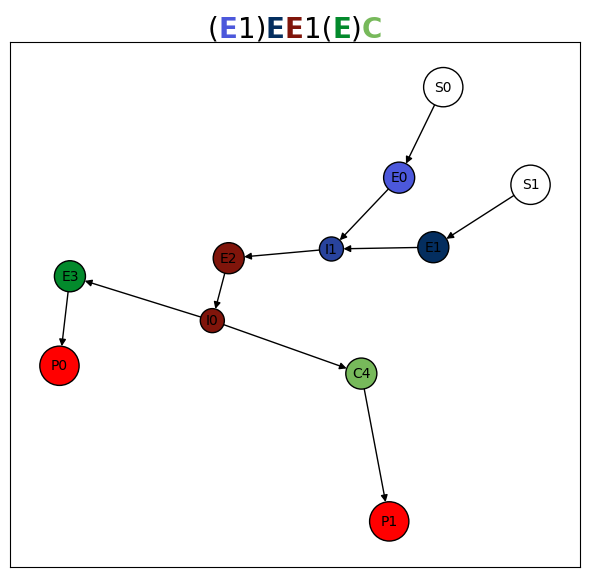

In [6]:
text = "(E1)EE1(E)C"
parser = SynthesisParser(text)
new_graph = parser.parse()  # do not overwrite original grap
new_graph_fleshed = insert_intermediates(new_graph)
draw_special(new_graph_fleshed, text)

In [7]:
text = "EC"
parser = SynthesisParser(text)
new_graph = parser.parse()  # do not overwrite original grap
G_with_intermediates = insert_intermediates(new_graph)

param_map = {
  "E0": {
    "type": "E",
    "params": [
      1,
      "oxidation",
      -0.6606283552286656,
      0.0002585607068571296,
      0.583403414766502
    ]
  },
  "C1": {
    "type": "C",
    "params": [
      1045.465719992965,
      0.0005773633594361184
    ]
  },
  "S0": {
    "type": "S",
    "params": 1
  },
  "I0": {
    "type": "I",
    "params": 0
  },
  "P0": {
    "type": "P",
    "params": 0
  }
}

model = None

comsol_params = {
    'startPotential': -1.0,
    'numCycles': 1,
    'vertexPotential1': 1.0,
    'vertexPotential2': -1.0,
    'endPotential': -1.0,
    'electrodeRadius': 1.0,  # mm
    'startScanRate': 0.0001,  # V/s
    'endScanRate': 100000.0,  # V/s  
    'scanRateCount': 5,
    'normalizeCurrent': True,
}

scan_rates = [0.01]

run_digisim_simulation(G_with_intermediates, param_map, model, comsol_params=comsol_params, scan_rates=scan_rates)

DigiSim scan rates: [0.01]
['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I0{SPACE}={SPACE}P0']
DigiSim simulation error: (-2147220991, 'An event was unable to invoke any of the subscribers', (None, None, None, 0, None))


Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 2725, in run_digisim_simulation
    view_button.child_window(title="View", control_type="Window").child_window(title="View", control_type="Menu").child_window(title="Preferences...", auto_id="32409", control_type="MenuItem").click_input()
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 379, in __getattribute__
    ctrls = self.__resolve_control(self.criteria)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:

{'error': "(-2147220991, 'An event was unable to invoke any of the subscribers', (None, None, None, 0, None))",
 'scan_rates': [0.01]}

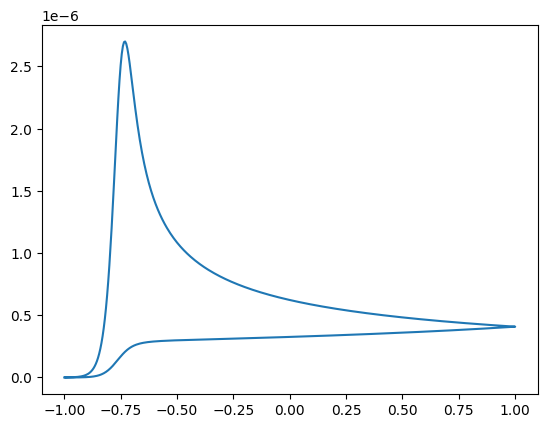

In [4]:
bad_run = pd.read_csv("EC/model_0101/model_0101_digisim_scan_scan_rate_1p00e-02_V_s.csv")
plt.plot(bad_run["E"], -bad_run['i'])

Core allocation: {'digisim': 1, 'ecsim': 3, 'electrokitty': 3, 'comsol': 11}


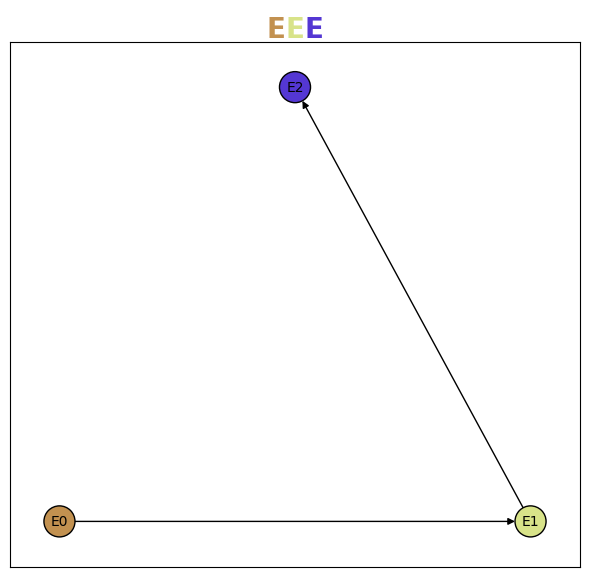

Generating 250 parameter maps for EEE mechanism sequentially...
Generating random param map with seed: 1
I entered the if condition!
I entered the if condition!
Generated param map: {'E0': {'type': 'E', 'params': (1, 'reduction', -0.4898619485211566, 2.876840498395757e-06, np.float64(0.5812172681831621))}, 'E1': {'type': 'E', 'params': (2, 'reduction', 0.3031859454455259, 0.001254614088923008, np.float64(0.46941217931749624))}, 'E2': {'type': 'E', 'params': (1, 'reduction', -0.9433050469559874, 0.0033257219382194594, np.float64(0.4735914123868272))}, 'S0': {'type': 'S', 'params': 1}, 'I0': {'type': 'I', 'params': 0}, 'I1': {'type': 'I', 'params': 0}, 'P0': {'type': 'P', 'params': 0}}
Generated parameters for model 0
Generating random param map with seed: 2
I entered the if condition!
I entered the if condition!
Generated param map: {'E0': {'type': 'E', 'params': (1, 'reduction', -0.8302560096821567, 0.0033074242259827375, np.float64(0.47916210762972644))}, 'E1': {'type': 'E', 'params':

Traceback (most recent call last):
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\timings.py", line 458, in wait_until_passes
    raise err
pywinauto.timings.TimeoutError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3144, in run_digisim_simulation
    E, i = run_simulation_and_extract()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3126, in run_simulation_and_extract
    main_window.child_window(title="File name:", auto_id="1152", control_type="Edit").type_keys("^a{DELETE}temp_file.use")
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Queues: Digisim=0(A:246), Ecsim=0(A:0), COMSOL=0(A:8), Electrokitty=0(A:0)
The number of active tasks is 254 while the repeat count is 0
Digisim lines ['PO+ Te =11', 'l1+2e=10', '10+ le =SO']
Normalized main ['P0+Te=11', '11+2e=10', '10+1e=+0']
Order_list: ['I1', 'I0', 'S0']
Reactions: ['I1{SPACE}{+}{SPACE}2e{SPACE}={SPACE}I0', 'I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0']
COMSOL task 0 timed out after 300s
A task (0) has completed in Lego City.
Queues: Digisim=0(A:246), Ecsim=0(A:0), COMSOL=0(A:7), Electrokitty=0(A:0)
The number of active tasks is 253 while the repeat count is 0
COMSOL task 4 timed out after 300s
A task (4) has completed in Lego City.
COMSOL task 6 timed out after 300s
A task (6) has completed in Lego City.
COMSOL: Starting model 13 (Active: 8)
COMSOL: Starting model 14 (Active: 8)
COMSOL: Starting model 15 (Active: 8)
Species order: ['I1', 'I0', 'S0']
Scrollbar found — will scroll as needed.
Found 3 visible boxes
Filled I1 with 0.0
Filled I0 with 0.0
Filled S0 with 0.001

Traceback (most recent call last):
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\timings.py", line 458, in wait_until_passes
    raise err
pywinauto.timings.TimeoutError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3144, in run_digisim_simulation
    E, i = run_simulation_and_extract()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3126, in run_simulation_and_extract
    main_window.child_window(title="File name:", auto_id="1152", control_type="Edit").type_keys("^a{DELETE}temp_file.use")
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Queues: Digisim=0(A:245), Ecsim=0(A:0), COMSOL=0(A:8), Electrokitty=0(A:0)
The number of active tasks is 253 while the repeat count is 0
Digisim lines ['PO+ Te =11', 'l1+1le=10', '10+ le =SO']
Normalized main ['P0+Te=11', '11+1e=10', '10+1e=+0']
Order_list: ['I1', 'I0', 'S0']
Reactions: ['I1{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0']
Species order: ['I1', 'I0', 'S0']
Scrollbar found — will scroll as needed.
Found 3 visible boxes
Filled I1 with 0.0
Queues: Digisim=0(A:245), Ecsim=0(A:0), COMSOL=0(A:8), Electrokitty=0(A:0)
The number of active tasks is 253 while the repeat count is 0
Filled I0 with 0.0
Filled S0 with 0.001
Queues: Digisim=0(A:245), Ecsim=0(A:0), COMSOL=0(A:8), Electrokitty=0(A:0)
The number of active tasks is 253 while the repeat count is 0
Running DigiSim simulation for scan rate: 0.01
COMSOL task 11 proved successful.
A task (11) has completed in Lego City.
I'm now doing the callback
I successfully entered the save.
I am saving to n

...

DigiSim simulation error: {'title': 'File name:', 'auto_id': '1152', 'control_type': 'Edit', 'top_level_only': False, 'parent': <uia_element_info.UIAElementInfo - 'DigiSim - CVSim1 - temp1', Afx:400000:8:10003:0:b2183, 401696>, 'backend': 'uia'}
A task (246) has completed in Lego City.
I'm now doing the callback
I successfully entered the save.
Error in digisim for model 246: 'str' object has no attribute 'keys'
DigiSim scan rates: [0.01, 0.1, 1.0, 10.0, 100.0]
['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I1{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'P0{SPACE}{+}{SPACE}2e{SPACE}={SPACE}I1']
Queues: Digisim=0(A:3), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 3 while the repeat count is 0
Digisim lines ['PO + 2e =11', 'l1+1le=10', '10+ le =SO']
Normalized main ['P0+2e=11', '11+1e=10', '10+1e=+0']
Order_list: ['P0', 'I1', 'I0', 'S0']
Reactions: ['P0{SPACE}{+}{SPACE}2e{SPACE}={SPACE}I1', 'I1{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'I0{SPACE}{+}{SPACE}1e{SPACE}={

Traceback (most recent call last):
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\timings.py", line 458, in wait_until_passes
    raise err
pywinauto.timings.TimeoutError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3144, in run_digisim_simulation
    E, i = run_simulation_and_extract()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3126, in run_simulation_and_extract
    main_window.child_window(title="File name:", auto_id="1152", control_type="Edit").type_keys("^a{DELETE}temp_file.use")
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

DigiSim simulation error: {'title': 'File name:', 'auto_id': '1152', 'control_type': 'Edit', 'top_level_only': False, 'parent': <uia_element_info.UIAElementInfo - 'DigiSim - CVSim1 - temp1', Afx:400000:8:10003:0:237a219b, 155983786>, 'backend': 'uia'}
A task (248) has completed in Lego City.
I'm now doing the callback
I successfully entered the save.
Error in digisim for model 248: 'str' object has no attribute 'keys'
DigiSim scan rates: [0.01, 0.1, 1.0, 10.0, 100.0]
['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I1{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'P0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I1']
Queues: Digisim=0(A:1), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 1 while the repeat count is 0
Digisim lines ['PO+ Te =11', 'l1+1le=10', '10+ le =SO']
Normalized main ['P0+Te=11', '11+1e=10', '10+1e=+0']
Order_list: ['I1', 'I0', 'S0']
Reactions: ['I1{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0']
Species order: ['I1', 'I0', 'S0'

Traceback (most recent call last):
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\timings.py", line 458, in wait_until_passes
    raise err
pywinauto.timings.TimeoutError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3144, in run_digisim_simulation
    E, i = run_simulation_and_extract()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3126, in run_simulation_and_extract
    main_window.child_window(title="File name:", auto_id="1152", control_type="Edit").type_keys("^a{DELETE}temp_file.use")
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Queues: Digisim=0(A:0), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 0 while the repeat count is 0
All queues empty and no active tasks
All simulations completed!
Queues: Digisim=0(A:0), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 0 while the repeat count is 0
All queues empty and no active tasks
Core allocation: {'digisim': 1, 'ecsim': 3, 'electrokitty': 3, 'comsol': 11}


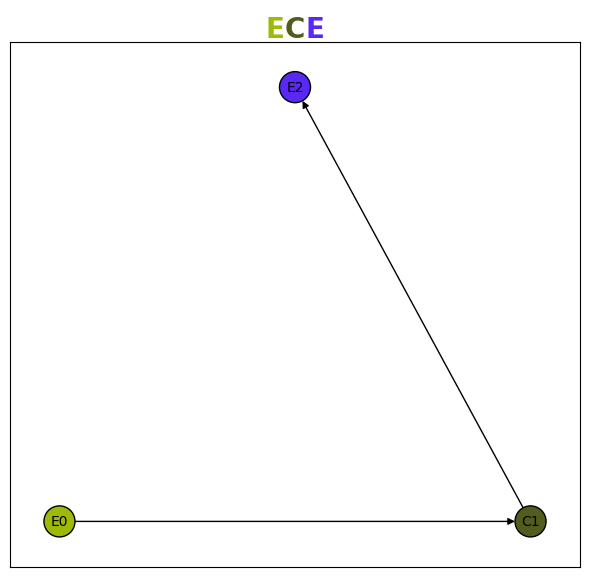

Generating 250 parameter maps for ECE mechanism sequentially...
Generating random param map with seed: 1
I entered the if condition!
'E1'
Generated param map: {'E0': {'type': 'E', 'params': (1, 'reduction', -0.4898619485211566, 2.876840498395757e-06, np.float64(0.5812172681831621))}, 'C1': {'type': 'C', 'params': (0.00017183931647566652, 0.014019377317960609)}, 'E2': {'type': 'E', 'params': (2, 'oxidation', 0.3031859454455259, 0.001254614088923008, np.float64(0.46941217931749624))}, 'S0': {'type': 'S', 'params': 1}, 'I0': {'type': 'I', 'params': 0}, 'I1': {'type': 'I', 'params': 0}, 'P0': {'type': 'P', 'params': 0}}
Generated parameters for model 0
Generating random param map with seed: 2
I entered the if condition!
'E1'
Generated param map: {'E0': {'type': 'E', 'params': (1, 'reduction', -0.8302560096821567, 0.0033074242259827375, np.float64(0.47916210762972644))}, 'C1': {'type': 'C', 'params': (3.9441165003638767, 0.16744366120809845)}, 'E2': {'type': 'E', 'params': (1, 'oxidation', 

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3065, in run_digisim_simulation
    parameter_window.type_keys(kf)
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\base_wrapper.py", line 937, in type_keys
    self.verify_actionable()
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\base_wrapper.py", line 681, in verify_actionable
    self.verify_enabled()
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\base_wrapper.py", line 692, in verify_enabled
    raise ElementNotEnabled()
pywinauto.base_wrapper.ElementNotEnabled


COMSOL task 3 proved successful.
A task (3) has completed in Lego City.
I'm now doing the callback
I successfully entered the save.
I am saving to new/ECE/model_0003/model_0003_comsol_scan_scan_rate_1p00e-02_V_s.csv
I am saving to new/ECE/model_0003/model_0003_comsol_scan_scan_rate_1p00e-01_V_s.csv
I am saving to new/ECE/model_0003/model_0003_comsol_scan_scan_rate_1p00e00_V_s.csv
I am saving to new/ECE/model_0003/model_0003_comsol_scan_scan_rate_1p00e01_V_s.csv
I am saving to new/ECE/model_0003/model_0003_comsol_scan_scan_rate_1p00e02_V_s.csv
Saved comsol results for model 3
COMSOL: Starting model 8 (Active: 8)
Queues: Digisim=0(A:248), Ecsim=0(A:0), COMSOL=0(A:8), Electrokitty=0(A:0)
The number of active tasks is 256 while the repeat count is 0
Digisim lines ['S0 + le = 10', '11+ le =P0']
Normalized main ['+0+1e=10', '11+1e=P0']
Order_list: ['S0', 'I0', 'I1', 'P0']
Reactions: ['S0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'I1{SPACE}{+}{SPACE}1e{SPACE}={SPACE}P0', 'I0{SPACE}={SPACE}I1']
Sp

Traceback (most recent call last):
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\timings.py", line 458, in wait_until_passes
    raise err
pywinauto.timings.TimeoutError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3144, in run_digisim_simulation
    E, i = run_simulation_and_extract()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3126, in run_simulation_and_extract
    main_window.child_window(title="File name:", auto_id="1152", control_type="Edit").type_keys("^a{DELETE}temp_file.use")
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

COMSOL task 19 proved successful.
A task (19) has completed in Lego City.
I'm now doing the callback
I successfully entered the save.
I am saving to new/ECE/model_0019/model_0019_comsol_scan_scan_rate_1p00e-02_V_s.csv
I am saving to new/ECE/model_0019/model_0019_comsol_scan_scan_rate_1p00e-01_V_s.csv
I am saving to new/ECE/model_0019/model_0019_comsol_scan_scan_rate_1p00e00_V_s.csv
I am saving to new/ECE/model_0019/model_0019_comsol_scan_scan_rate_1p00e01_V_s.csv
I am saving to new/ECE/model_0019/model_0019_comsol_scan_scan_rate_1p00e02_V_s.csv
Saved comsol results for model 19
COMSOL: Starting model 26 (Active: 8)
Queues: Digisim=0(A:244), Ecsim=0(A:0), COMSOL=0(A:8), Electrokitty=0(A:0)
The number of active tasks is 252 while the repeat count is 0
Digisim lines ['S0 + le = 10', '11 +2e =P0']
Normalized main ['+0+1e=10', '11+2e=P0']
Order_list: ['S0', 'I0', 'I1', 'P0']
Reactions: ['S0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'I1{SPACE}{+}{SPACE}2e{SPACE}={SPACE}P0', 'I0{SPACE}={SPACE}I1'

...

Queues: Digisim=0(A:11), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 11 while the repeat count is 0
Digisim lines ['S0 + le = 10', 'PO + 2e =11']
Normalized main ['+0+1e=10', 'P0+2e=11']
Order_list: ['S0', 'I0', 'P0', 'I1']
Reactions: ['S0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}I0', 'P0{SPACE}{+}{SPACE}2e{SPACE}={SPACE}I1', 'I0{SPACE}={SPACE}I1']
Species order: ['S0', 'I0', 'P0', 'I1']
Scrollbar found — will scroll as needed.
Queues: Digisim=0(A:11), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 11 while the repeat count is 0
Found 3 visible boxes
Filled S0 with 0.001
Filled I0 with 0.0
Filled P0 with 0.0
Filled I1 with 0.0 (after scrolling)
Queues: Digisim=0(A:11), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 11 while the repeat count is 0
Running DigiSim simulation for scan rate: 0.01
Queues: Digisim=0(A:11), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 11

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3065, in run_digisim_simulation
    parameter_window.type_keys(kf)
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\base_wrapper.py", line 937, in type_keys
    self.verify_actionable()
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\base_wrapper.py", line 681, in verify_actionable
    self.verify_enabled()
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\base_wrapper.py", line 692, in verify_enabled
    raise ElementNotEnabled()
pywinauto.base_wrapper.ElementNotEnabled


Queues: Digisim=0(A:3), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 3 while the repeat count is 0
Digisim lines ['10+ le =SO', 'PO+ Te =11']
Normalized main ['10+1e=+0', 'P0+Te=11']
Order_list: ['I0', 'S0', 'I1']
Reactions: ['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I0{SPACE}={SPACE}I1']
Species order: ['I0', 'S0', 'I1']
Scrollbar found — will scroll as needed.
Found 3 visible boxes
Filled I0 with 0.0
Filled S0 with 0.001
Filled I1 with 0.0
Queues: Digisim=0(A:3), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 3 while the repeat count is 0
Running DigiSim simulation for scan rate: 0.01
Queues: Digisim=0(A:3), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 3 while the repeat count is 0


Traceback (most recent call last):
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\application.py", line 250, in __resolve_control
    ctrl = wait_until_passes(
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\anaconda3\envs\echo_executable\Lib\site-packages\pywinauto\timings.py", line 458, in wait_until_passes
    raise err
pywinauto.timings.TimeoutError

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3144, in run_digisim_simulation
    E, i = run_simulation_and_extract()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\LabLu\COMSOL\Connor\Graphs\ece_simulation_final\simulation_utils.py", line 3126, in run_simulation_and_extract
    main_window.child_window(title="File name:", auto_id="1152", control_type="Edit").type_keys("^a{DELETE}temp_file.use")
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

DigiSim simulation error: {'title': 'File name:', 'auto_id': '1152', 'control_type': 'Edit', 'top_level_only': False, 'parent': <uia_element_info.UIAElementInfo - 'DigiSim - CVSim1 - temp1', Afx:400000:8:10003:0:1eae66db, 92006>, 'backend': 'uia'}
A task (247) has completed in Lego City.
I'm now doing the callback
I successfully entered the save.
Error in digisim for model 247: 'str' object has no attribute 'keys'
DigiSim scan rates: [0.01, 0.1, 1.0, 10.0, 100.0]
['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I0{SPACE}={SPACE}I1', 'I1{SPACE}{+}{SPACE}2e{SPACE}={SPACE}P0']
Queues: Digisim=0(A:2), Ecsim=0(A:0), COMSOL=0(A:0), Electrokitty=0(A:0)
The number of active tasks is 2 while the repeat count is 0
Digisim lines ['10+ le =SO', '11 +2e =P0']
Normalized main ['10+1e=+0', '11+2e=P0']
Order_list: ['I0', 'S0', 'I1', 'P0']
Reactions: ['I0{SPACE}{+}{SPACE}1e{SPACE}={SPACE}S0', 'I1{SPACE}{+}{SPACE}2e{SPACE}={SPACE}P0', 'I0{SPACE}={SPACE}I1']
Species order: ['I0', 'S0', 'I1', 'P0']
Scrollbar f

In [ ]:
mechanisms = ["EEE", "ECE"]
for mechanism in mechanisms:
    # Instantiate the mechanism
    runner = GeneralSimulationRunner(
        mechanism=mechanism,
        num_simulations=250,
        random_state=1,
        total_cores=16
    )


    # Generate the parameter maps for that mechanism
    runner.generate_all_param_maps()

    # Run all the simulations
    runner.run_all_simulations_parallel()

    # Wait for the given task to complete 
    runner._wait_for_queues_to_empty()


Core allocation: {'digisim': 1, 'ecsim': 3, 'electrokitty': 3, 'comsol': 11}


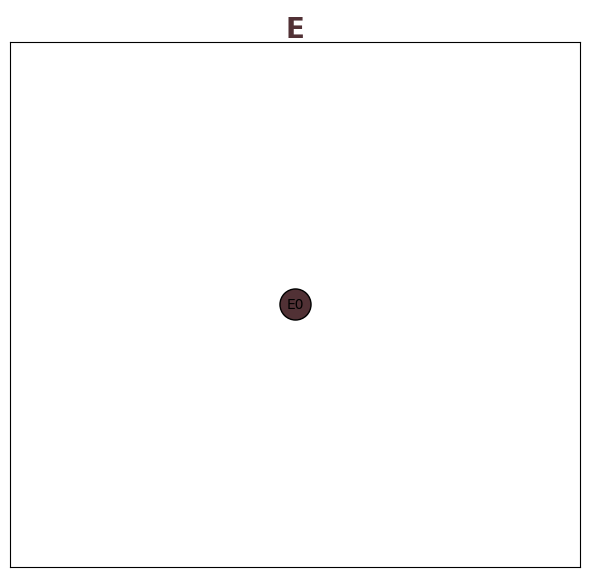

No base directory found. Using the runner's mechanism
Scanning 250 model directories for failed Electrokitty simulations...
Rerunning due to failure: Insufficient data points (0 < 100)
  Submitting rerun for model 0...
Electrokitty: Processing model 0 (Active: 0/3)
Rerunning due to failure: Insufficient data points (0 < 100)
  Submitting rerun for model 1...
Electrokitty: Processing model 1 (Active: 1/3)
Rerunning due to failure: Insufficient data points (0 < 100)
  Submitting rerun for model 2...
Electrokitty: Processing model 2 (Active: 2/3)
Rerunning due to failure: Insufficient data points (0 < 100)
  Submitting rerun for model 3...
Electrokitty: Processing model 3 (Active: 3/3)
Rerunning due to failure: Insufficient data points (0 < 100)
  Submitting rerun for model 4...
Electrokitty: Processing model 4 (Active: 4/3)
Rerunning due to failure: Insufficient data points (0 < 100)
  Submitting rerun for model 5...
Electrokitty: Processing model 5 (Active: 5/3)
Rerunning due to failure

In [ ]:
mechanisms = ["E"] #["EC", "CE", "ECE","CEC"] #"EE", "EEE", "CEE", "EEC", "(E1)CE1", 
for mechanism in mechanisms:
    # Instantiate the mechanism
    runner = GeneralSimulationRunner(
        mechanism=mechanism,
        num_simulations=250,
        random_state=1,
        total_cores=16
    )

    # Generate the parameter maps for that mechanism
    rerun_failed_electrokitty(base_dir='.', runner=runner)

    # Wait for the given task to complete 
    runner._wait_for_queues_to_empty()
